### Evalutor graph yani ai ni ozi bilan ozini muloqot qildirib natijani yaxshilab chiqarish uchun ishlatiladi !

In [74]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
import os

load_dotenv()

API_KEY = os.getenv("GEMINI_API_KEY")
llm = ChatGoogleGenerativeAI(api_key=API_KEY, model="gemini-3-flash-preview")


In [75]:
from pydantic import BaseModel, Field
from typing import Literal, TypedDict


class llm_schema(BaseModel):
    image_prompt: str = Field(..., description="Image prompt")
    image_feedback: str = Field(..., description="Rasim prompti haqida fikr-mulohazalar")
    aproved: Literal["yes", "no"]


llm_with_schema = llm.with_structured_output(llm_schema)


In [76]:
class graph_schema(TypedDict):
    topic: str
    image_prompt: str
    image_feedback: str
    aproved_all: str
    takrorlanishlar: int
    max_takrorlanish: int

In [77]:
def generate_prompt_image(state: graph_schema) -> graph_schema:
    topic = state["topic"]
    image_feedback = state["image_feedback"]
    if not image_feedback:
        response = llm.invoke(
            f"Shu {topic} mavzuda kulgili karton uchun professional darajada prompt yaratib berishingiz kerak! Hazil juda ham real va ishonchli bo'lishi shart !")
    else:
        response = llm.invoke(
            f"Shu mavzuda {topic} juda ham kulgili rasim uchun prompt yozishingiz kerak bo'ladi.  Fikr-mulohazalar: {image_feedback} ")

    state["image_prompt"] = response.content[0]['text']
    return state



In [78]:
def evalutor_node(state: graph_schema) -> graph_schema:
    prompt = ChatPromptTemplate.from_messages([
        ('system',
         "Siz juda talabchan tanqidchisiz! Faqat AJOYIB, kutilmagan va professional darajada kulgili bo'lgan promptlarga 'yes' bering. Oddiy yoki kulgili bo'lmagan tomonlari bo'lsa — 'no' bering va 'image_feedback'da aniq nima yetishmayotganini yozing."),
        ('human', "Mana rasim uchun prompt {image_prompt}")
    ])
    chain = prompt | llm_with_schema
    response = chain.invoke({"image_prompt": state["image_prompt"]})
    state["aproved_all"] = response.aproved
    state['image_feedback'] = response.image_feedback
    if response.aproved != 'yes':
        state['takrorlanishlar'] += 1

    return state

In [79]:
def check_node(state: graph_schema) -> graph_schema:
    if state["aproved_all"] == "yes":
        return "end"
    if state['takrorlanishlar'] >= state['max_takrorlanish']:
        return "end"
    else:
        return "generate_prompt"

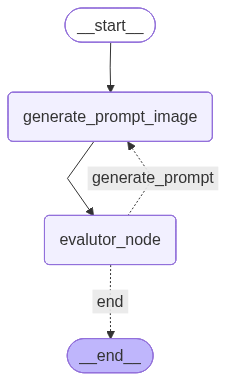

In [80]:
from langgraph.graph import START, StateGraph, END

graph = StateGraph(graph_schema)

graph.add_node("generate_prompt_image", generate_prompt_image)
graph.add_node("evalutor_node", evalutor_node)

graph.add_edge(START, "generate_prompt_image")
graph.add_edge("generate_prompt_image", "evalutor_node")
graph.add_conditional_edges("evalutor_node", check_node, {
    "end": END,
    "generate_prompt": "generate_prompt_image",
})

evalutor_graph = graph.compile()

from IPython.display import display, Image

display(Image(evalutor_graph.get_graph().draw_mermaid_png()))

In [81]:
# topic: str
# image_prompt: str
# image_feedback: str
# aproved_all: str
# takrorlanishlar: int
# max_takrorlanish: int

yakuniy_natija = evalutor_graph.invoke({
    "topic": "Fudbo'lda Cristiano va Messi",
    "image_prompt": "",
    "image_feedback": "",
    "aproved_all": "",
    "takrorlanishlar": 0,
    "max_takrorlanish": 5,
})
yakuniy_natija

{'topic': "Fudbo'lda Cristiano va Messi",
 'image_prompt': 'Sizning fikr-mulohazalaringiz o‘rinli. Haqiqatan ham "mehnatkash va iste’dod" qarama-qarshiligi juda eskirgan. Haqiqiy kulgili va kutilmagan syujet yaratish uchun ularni odatdagi muhitidan (stadiondan) chiqarib, absurd va insoniy vaziyatlarga tushirish kerak.\n\nMana, kutilmagan burilishlarga ega, professional karikatura va 3D renderlar uchun 4 ta yangi va original prompt:\n\n### 1. "Oshxonadagi GOATlar" (Absurd komediya)\n**G\'oya:** Ronaldu va Messi birgalikda o‘zbekcha osh damlayotganini tasavvur qiling.\n> **Prompt:** Professional caricature, Pixar style 3D render. Cristiano Ronaldo and Lionel Messi in a chaotic kitchen. Ronaldo is intensely "Siuuu-ing" while throwing salt into a giant steaming pot of Plov from a 3-meter height (Salt Bae style), his face showing extreme concentration. Messi, sitting on a tiny stool, is dribbling a potato through a forest of falling onion rings with magical ease. The twist: The World Cup tr